In [ ]:
import requests

In [ ]:
URL = "https://meowfacts.herokuapp.com/" # get random fact
result = requests.get(URL)
print(result.json()['data'])

['Cats can not taste sweetness.']


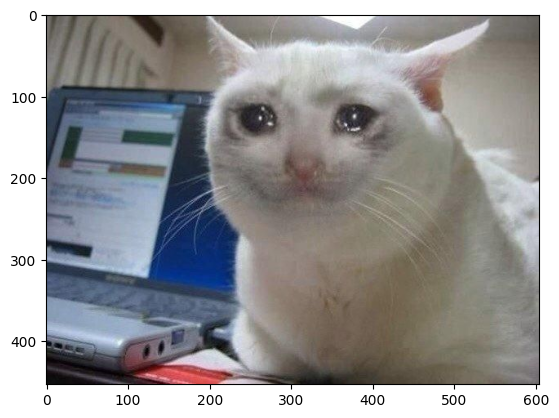

In [ ]:
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO

URL ="https://cataas.com/cat"

result = requests.get(URL)
im = Image.open(BytesIO(result.content))
plt.imshow(im)
plt.show()

## NCBI Example

In [ ]:
#Send post request
api_url = 'https://api.ncbi.nlm.nih.gov/datasets/v2'
request_url = '/gene/dataset_report'

response = requests.post(url=api_url+request_url,
                        json={
  "gene_ids": [
    59067,
    50615
  ]
})
response.json()

{'reports': [{'gene': {'gene_id': '59067',
    'symbol': 'IL21',
    'description': 'interleukin 21',
    'tax_id': '9606',
    'taxname': 'Homo sapiens',
    'common_name': 'human',
    'type': 'PROTEIN_CODING',
    'orientation': 'minus',
    'reference_standards': [{'gene_range': {'accession_version': 'NG_031966.2',
       'range': [{'begin': '5001', 'end': '15959', 'orientation': 'plus'}]},
      'type': 'REFSEQ_GENE'}],
    'chromosomes': ['4'],
    'nomenclature_authority': {'authority': 'HGNC', 'identifier': 'HGNC:6005'},
    'swiss_prot_accessions': ['Q9HBE4'],
    'ensembl_gene_ids': ['ENSG00000138684'],
    'omim_ids': ['605384'],
    'synonyms': ['Za11', 'IL-21', 'CVID11'],
    'annotations': [{'assembly_accession': 'GCF_000001405.40',
      'assembly_name': 'GRCh38.p14',
      'annotation_name': 'GCF_000001405.40-RS_2025_08',
      'annotation_release_date': '2025-08-01',
      'genomic_locations': [{'genomic_accession_version': 'NC_000004.12',
        'sequence_name': '4',

In [ ]:
#Parse response with AI
import pandas as pd


In [ ]:
import pandas as pd

parsed_data = []
for report in response.json()['reports']:
    gene = report['gene']

    gene_id = gene.get('gene_id')
    description_type = gene.get('description') # Mapping 'description' to 'description_type' as requested
    gene_type = gene.get('type') # Renamed to avoid conflict with Python's built-in type
    orientation = gene.get('orientation')

    assembly_accession = None
    assembly_name = None
    genomic_locations_begin = None
    genomic_locations_end = None

    if gene.get('annotations') and len(gene['annotations']) > 0:
        first_annotation = gene['annotations'][0]
        assembly_accession = first_annotation.get('assembly_accession')
        assembly_name = first_annotation.get('assembly_name')

        if first_annotation.get('genomic_locations') and len(first_annotation['genomic_locations']) > 0:
            first_genomic_location = first_annotation['genomic_locations'][0]
            if first_genomic_location.get('genomic_range'):
                genomic_locations_begin = first_genomic_location['genomic_range'].get('begin')
                genomic_locations_end = first_genomic_location['genomic_range'].get('end')

    parsed_data.append({
        'gene_id': gene_id,
        'description_type': description_type,
        'type': gene_type,
        'orientation': orientation,
        'assembly_accession': assembly_accession,
        'assembly_name': assembly_name,
        'genomic_locations_begin': genomic_locations_begin,
        'genomic_locations_end': genomic_locations_end
    })

df_parsed = pd.DataFrame(parsed_data)
print(df_parsed.to_markdown(index=False))

|   gene_id | description_type        | type           | orientation   | assembly_accession   | assembly_name   |   genomic_locations_begin |   genomic_locations_end |
|----------:|:------------------------|:---------------|:--------------|:---------------------|:----------------|--------------------------:|------------------------:|
|     59067 | interleukin 21          | PROTEIN_CODING | minus         | GCF_000001405.40     | GRCh38.p14      |                 122610108 |               122621066 |
|     50615 | interleukin 21 receptor | PROTEIN_CODING | plus          | GCF_000001405.40     | GRCh38.p14      |                  27402174 |                27452042 |


In [ ]:
#Parse whole response
import pandas as pd
data = [el['gene'] for el in response.json()['reports']]

df = pd.DataFrame(data)
df

,gene_id,symbol,description,tax_id,taxname,common_name,type,orientation,reference_standards,chromosomes,...,ensembl_gene_ids,omim_ids,synonyms,annotations,transcript_count,protein_count,transcript_type_counts,gene_groups,summary,gene_ontology
0,59067,IL21,interleukin 21,9606,Homo sapiens,human,PROTEIN_CODING,minus,[{'gene_range': {'accession_version': 'NG_0319...,[4],...,[ENSG00000138684],[605384],"[Za11, IL-21, CVID11]","[{'assembly_accession': 'GCF_000001405.40', 'a...",2,2,"[{'type': 'PROTEIN_CODING', 'count': 2}]","[{'id': '59067', 'method': 'NCBI Ortholog'}]",[{'description': 'This gene encodes a member o...,{'molecular_functions': [{'name': 'cytokine ac...
1,50615,IL21R,interleukin 21 receptor,9606,Homo sapiens,human,PROTEIN_CODING,plus,[{'gene_range': {'accession_version': 'NG_0122...,[16],...,[ENSG00000103522],[605383],"[NILR, CD360, IMD56]","[{'assembly_accession': 'GCF_000001405.40', 'a...",8,8,"[{'type': 'PROTEIN_CODING', 'count': 3}, {'typ...","[{'id': '50615', 'method': 'NCBI Ortholog'}]",[{'description': 'The protein encoded by this ...,{'molecular_functions': [{'name': 'cytokine re...


In [ ]:
#Find genome


request_url = '/taxonomy'

response = requests.post(url=api_url+request_url,
                        json={
  "taxons": [
    "HIV"
  ]
})
tax_id = response.json()['taxonomy_nodes'][0]['taxonomy']['tax_id']

get_request_url = f'/genome/taxon/{tax_id}/dataset_report'
response = requests.get(url=api_url+get_request_url)
accession = response.json()['reports'][0]['accession']
accession

'GCA_000864765.1'

## Download genome and extract zip to disk

In [ ]:
# Download genome
import zipfile
from io import BytesIO

request_url = '/genome/download'

request_body = {

  "accessions": [
    accession
  ],
  "include_annotation_type": [
    "GENOME_FASTA"
  ]

}

response = requests.post(url=api_url+request_url, json=request_body)
zip_bytes = BytesIO(response.content)

with zipfile.ZipFile(zip_bytes, 'r') as zip_ref:
  zip_ref.extractall(accession)


## Get file value without extracting zip archive

In [ ]:
import pandas as pd

with zipfile.ZipFile(zip_bytes, 'r') as zip_ref:
  file_list = pd.Series([el.filename for el in  zip_ref.filelist])
  file_name = file_list[file_list.str.contains('.fna')].iloc[0]
  genome_bytes = zip_ref.read(file_name)
  genome_string = genome_bytes.decode('UTF-8')
genome_string

'>AF033819.3 HIV-1, complete genome\nGGTCTCTCTGGTTAGACCAGATCTGAGCCTGGGAGCTCTCTGGCTAACTAGGGAACCCACTGCTTAAGCCTCAATAAAGC\nTTGCCTTGAGTGCTTCAAGTAGTGTGTGCCCGTCTGTTGTGTGACTCTGGTAACTAGAGATCCCTCAGACCCTTTTAGTC\nAGTGTGGAAAATCTCTAGCAGTGGCGCCCGAACAGGGACCTGAAAGCGAAAGGGAAACCAGAGGAGCTCTCTCGACGCAG\nGACTCGGCTTGCTGAAGCGCGCACGGCAAGAGGCGAGGGGCGGCGACTGGTGAGTACGCCAAAAATTTTGACTAGCGGAG\nGCTAGAAGGAGAGAGATGGGTGCGAGAGCGTCAGTATTAAGCGGGGGAGAATTAGATCGATGGGAAAAAATTCGGTTAAG\nGCCAGGGGGAAAGAAAAAATATAAATTAAAACATATAGTATGGGCAAGCAGGGAGCTAGAACGATTCGCAGTTAATCCTG\nGCCTGTTAGAAACATCAGAAGGCTGTAGACAAATACTGGGACAGCTACAACCATCCCTTCAGACAGGATCAGAAGAACTT\nAGATCATTATATAATACAGTAGCAACCCTCTATTGTGTGCATCAAAGGATAGAGATAAAAGACACCAAGGAAGCTTTAGA\nCAAGATAGAGGAAGAGCAAAACAAAAGTAAGAAAAAAGCACAGCAAGCAGCAGCTGACACAGGACACAGCAATCAGGTCA\nGCCAAAATTACCCTATAGTGCAGAACATCCAGGGGCAAATGGTACATCAGGCCATATCACCTAGAACTTTAAATGCATGG\nGTAAAAGTAGTAGAAGAGAAGGCTTTCAGCCCAGAAGTGATACCCATGTTTTCAGCATTATCAGAAGGAGCCACCCCACA\nAGATTTAAACACCATGCTAAACACAGTGGGGGGACATCAAGCAGCCATGCAAATGTTAAAA

#Uniprot example

In [ ]:
### query on Uniprote site for:
# * fructokinase
# * escherichia coli
# * reviewed

# a) site search in https://www.uniprot.org/
#   (pay attention to search field and URL field)

# b) search for "Uniprot API" syntax
#    -- REST is a principle of data transmission
#    -- retrieving entries via queries

# try to put into URL filed in your browser
# https://www.uniprot.org/uniprot/?query=protein_name:fructokinase+AND+organism_name:escherichia coli+AND+reviewed:true

In [ ]:
URL = "https://rest.uniprot.org/uniprotkb/search?" \
      "query=(protein_name:Fructokinase)" \
      " AND (organism_name:'Escherichia coli')" \
      " AND (reviewed:true)" \
      "&format=txt" # list, json, txt, tab, xml, json, fasta

In [ ]:
URL

"https://rest.uniprot.org/uniprotkb/search?query=(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)&format=txt"

In [ ]:
result = requests.get(URL)

## Analyze response

In [ ]:
result # The HTTP 200 OK success status response code indicates that the request has succeeded.

<Response [200]>

In [ ]:
result.ok

True

In [ ]:
result.text[:1000]

'ID   MAK_ECOLI               Reviewed;         302 AA.\nAC   P23917; P71316; P75705; Q2MC31;\nDT   01-MAR-1992, integrated into UniProtKB/Swiss-Prot.\nDT   01-JUN-1994, sequence version 2.\nDT   05-FEB-2025, entry version 152.\nDE   RecName: Full=Fructokinase;\nDE            EC=2.7.1.4;\nDE   AltName: Full=D-fructose kinase;\nDE   AltName: Full=Manno(fructo)kinase;\nGN   Name=mak; Synonyms=yajF; OrderedLocusNames=b0394, JW0385;\nOS   Escherichia coli (strain K12).\nOC   Bacteria; Pseudomonadota; Gammaproteobacteria; Enterobacterales;\nOC   Enterobacteriaceae; Escherichia.\nOX   NCBI_TaxID=83333;\nRN   [1]\nRP   NUCLEOTIDE SEQUENCE [GENOMIC DNA].\nRC   STRAIN=K12;\nRX   PubMed=8807285; DOI=10.1093/genetics/143.3.1101;\nRA   Ryder L., Sharples G.J., Lloyd R.G.;\nRT   "Recombination-dependent growth in exonuclease-depleted recBC sbcBC strains\nRT   of Escherichia coli K-12.";\nRL   Genetics 143:1101-1114(1996).\nRN   [2]\nRP   NUCLEOTIDE SEQUENCE [LARGE SCALE GENOMIC DNA].\nRC   STRAIN=K

In [ ]:
if result.ok:
#   print(result.text)
    print("==")
    print(result.headers)
else:
    print('Something went wrong ', result.status_code)

==
{'Vary': 'accept,accept-encoding,x-uniprot-release,x-api-deployment-date, User-Agent', 'Cache-Control': 'public, max-age=43200', 'x-cache': 'miss cached', 'Content-Type': 'text/plain;format=flatfile', 'Content-Encoding': 'gzip', 'Access-Control-Allow-Credentials': 'true', 'Access-Control-Expose-Headers': 'Link, X-Total-Results, X-UniProt-Release, X-UniProt-Release-Date, X-API-Deployment-Date', 'X-API-Deployment-Date': '05-February-2025', 'Strict-Transport-Security': 'max-age=31536000; includeSubDomains', 'Date': 'Wed, 19 Mar 2025 15:27:06 GMT', 'Access-Control-Max-Age': '1728000', 'X-UniProt-Release': '2025_01', 'X-Total-Results': '2', 'Transfer-Encoding': 'chunked', 'Access-Control-Allow-Origin': '*', 'Accept-Ranges': 'bytes', 'Connection': 'keep-alive', 'Access-Control-Allow-Methods': 'GET, PUT, POST, DELETE, PATCH, OPTIONS', 'Access-Control-Allow-Headers': 'DNT,Keep-Alive,User-Agent,X-Requested-With,If-Modified-Since,Cache-Control,Content-Type,Range,Authorization', 'X-UniProt-Rel

In [ ]:
for key, value in result.headers.items():
    print('ITEM {}: {}'.format(key, value))

ITEM Vary: accept,accept-encoding,x-uniprot-release,x-api-deployment-date, User-Agent
ITEM Cache-Control: public, max-age=43200
ITEM x-cache: miss cached
ITEM Content-Type: text/plain;format=flatfile
ITEM Content-Encoding: gzip
ITEM Access-Control-Allow-Credentials: true
ITEM Access-Control-Expose-Headers: Link, X-Total-Results, X-UniProt-Release, X-UniProt-Release-Date, X-API-Deployment-Date
ITEM X-API-Deployment-Date: 05-February-2025
ITEM Strict-Transport-Security: max-age=31536000; includeSubDomains
ITEM Date: Wed, 19 Mar 2025 15:27:06 GMT
ITEM Access-Control-Max-Age: 1728000
ITEM X-UniProt-Release: 2025_01
ITEM X-Total-Results: 2
ITEM Transfer-Encoding: chunked
ITEM Access-Control-Allow-Origin: *
ITEM Accept-Ranges: bytes
ITEM Connection: keep-alive
ITEM Access-Control-Allow-Methods: GET, PUT, POST, DELETE, PATCH, OPTIONS
ITEM Access-Control-Allow-Headers: DNT,Keep-Alive,User-Agent,X-Requested-With,If-Modified-Since,Cache-Control,Content-Type,Range,Authorization
ITEM X-UniProt-Rel

## List format

In [ ]:
URL = "https://rest.uniprot.org/uniprotkb/search?" \
      "query=(protein_name:Fructokinase)" \
      " AND (organism_name:'Escherichia coli')" \
      " AND (reviewed:true)" \
      "&format=list"  # list, json, txt, tab, xml, json, fasta

In [ ]:
# Another way to pass data into requests.get

database = 'https://rest.uniprot.org'
endpoint = '/uniprotkb/search' # Knowledgebase
params = {'query': "(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)", # try typo
           'format': 'list'}

result = requests.get(database + endpoint, params=params)

In [ ]:
params

{'query': "(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)",
 'format': 'list'}

In [ ]:
result

<Response [200]>

In [ ]:
if result.ok:
    print(result.text)
else:
    print('Something went wrong ', result.status_code)

P23917
P40713



In [ ]:
result.text

'P23917\nP40713\n'

## Fasta format

In [ ]:
# try other formats: fasta, xml, ..
database = 'https://rest.uniprot.org'
endpoint = '/uniprotkb/search' # Knowledgebase
params = {'query': "(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)", # try typo
           'format': 'fasta'}
           #'columns': 'id,entry_name,ec,chebi-id'
result = requests.get(database + endpoint, params=params)

In [ ]:
if result.ok:
    print(result.text)
else:
    print('Something went wrong ', result.status_code)

>sp|P23917|MAK_ECOLI Fructokinase OS=Escherichia coli (strain K12) OX=83333 GN=mak PE=1 SV=2
MRIGIDLGGTKTEVIALGDAGEQLYRHRLPTPRDDYRQTIETIATLVDMAEQATGQRGTV
GMGIPGSISPYTGVVKNANSTWLNGQPFDKDLSARLQREVRLANDANCLAVSEAVDGAAA
GAQTVFAVIIGTGCGAGVAFNGRAHIGGNGTAGEWGHNPLPWMDEDELRYREEVPCYCGK
QGCIETFISGTGFAMDYRRLSGHALKGSEIIRLVEESDPVAELALRRYELRLAKSLAHVV
NILDPDVIVLGGGMSNVDRLYQTVGQLIKQFVFGGECETPVRKAKHGDSSGVRGAAWLWP
QE
>sp|P40713|SCRK_ECOLX Fructokinase OS=Escherichia coli OX=562 GN=cscK PE=3 SV=2
MSAKVWVLGDAVVDLLPESDGRLLPCPGGAPANVAVGIARLGGTSGFIGRVGDDPFGALM
QRTLLTEGVDITYLKQDEWHRTSTVLVDLNDQGERSFTFMVRPSADLFLETTDLPCWRHG
EWLHLCSIALSAEPSRTSAFTAMTAIRHAGGFVSFDPNIREDLWQDEHLLRLCLRQALQL
ADVVKLSEEEWRLISGKTQNDRDICALAKEYEIAMLLVTKGAEGVVVCYRGQVHHFAGMS
VNCVDSTGAGDAFVAGLLTGLSSTGLSTDEREMRRIIDLAQRCGALAVTAKGAMTALPCR
QELESEK



## Tab format

In [ ]:
database = 'https://rest.uniprot.org'
endpoint = '/uniprotkb/search' # Knowledgebase
params = {'query': "(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)",
           'format': 'tsv'}
result = requests.get(database + endpoint, params=params)

In [ ]:
if result.ok:
    print(result.text)
else:
    print('Something went wrong ', result.status_code)

Entry	Entry Name	Reviewed	Protein names	Gene Names	Organism	Length
P23917	MAK_ECOLI	reviewed	Fructokinase (EC 2.7.1.4) (D-fructose kinase) (Manno(fructo)kinase)	mak yajF b0394 JW0385	Escherichia coli (strain K12)	302
P40713	SCRK_ECOLX	reviewed	Fructokinase (EC 2.7.1.4)	cscK	Escherichia coli	307



In [ ]:
result.text

'Entry\tEntry Name\tReviewed\tProtein names\tGene Names\tOrganism\tLength\nP23917\tMAK_ECOLI\treviewed\tFructokinase (EC 2.7.1.4) (D-fructose kinase) (Manno(fructo)kinase)\tmak yajF b0394 JW0385\tEscherichia coli (strain K12)\t302\nP40713\tSCRK_ECOLX\treviewed\tFructokinase (EC 2.7.1.4)\tcscK\tEscherichia coli\t307\n'

## XML format

In [ ]:
URL = "https://rest.uniprot.org/uniprotkb/search?" \
      "query=(protein_name:Fructokinase)" \
      " AND (organism_name:'Escherichia coli')" \
      " AND (reviewed:true)" \
      "&format=xml"

result = requests.get(URL)
print(URL)

https://rest.uniprot.org/uniprotkb/search?query=(protein_name:Fructokinase) AND (organism_name:'Escherichia coli') AND (reviewed:true)&format=xml


In [ ]:
if result.ok:
    print(result.text[:100])
else:
    print('Something went wrong ', result.status_code)

<?xml version="1.0" encoding="UTF-8"  standalone="no" ?>
<uniprot xmlns="http://uniprot.org/uniprot"


In [ ]:
!pip install xmltodict

In [ ]:
import xmltodict

xml_result = xmltodict.parse(result.text)

In [ ]:
xml_result

{'uniprot': {'@xmlns': 'http://uniprot.org/uniprot',
  '@xmlns:xsi': 'http://www.w3.org/2001/XMLSchema-instance',
  '@xsi:schemaLocation': 'http://uniprot.org/uniprot http://www.uniprot.org/docs/uniprot.xsd',
  'entry': [{'@dataset': 'Swiss-Prot',
    '@created': '1992-03-01',
    '@modified': '2025-02-05',
    '@version': '152',
    '@xmlns': 'http://uniprot.org/uniprot',
    'accession': ['P23917', 'P71316', 'P75705', 'Q2MC31'],
    'name': 'MAK_ECOLI',
    'protein': {'recommendedName': {'fullName': 'Fructokinase',
      'ecNumber': '2.7.1.4'},
     'alternativeName': [{'fullName': 'D-fructose kinase'},
      {'fullName': 'Manno(fructo)kinase'}]},
    'gene': {'name': [{'@type': 'primary', '#text': 'mak'},
      {'@type': 'synonym', '#text': 'yajF'},
      {'@type': 'ordered locus', '#text': 'b0394'},
      {'@type': 'ordered locus', '#text': 'JW0385'}]},
    'organism': {'name': {'@type': 'scientific',
      '#text': 'Escherichia coli (strain K12)'},
     'dbReference': {'@type': '

In [ ]:
len(xml_result["uniprot"]["entry"])

2

In [ ]:
xml_result["uniprot"]["entry"][0]

{'@dataset': 'Swiss-Prot',
 '@created': '1992-03-01',
 '@modified': '2025-02-05',
 '@version': '152',
 '@xmlns': 'http://uniprot.org/uniprot',
 'accession': ['P23917', 'P71316', 'P75705', 'Q2MC31'],
 'name': 'MAK_ECOLI',
 'protein': {'recommendedName': {'fullName': 'Fructokinase',
   'ecNumber': '2.7.1.4'},
  'alternativeName': [{'fullName': 'D-fructose kinase'},
   {'fullName': 'Manno(fructo)kinase'}]},
 'gene': {'name': [{'@type': 'primary', '#text': 'mak'},
   {'@type': 'synonym', '#text': 'yajF'},
   {'@type': 'ordered locus', '#text': 'b0394'},
   {'@type': 'ordered locus', '#text': 'JW0385'}]},
 'organism': {'name': {'@type': 'scientific',
   '#text': 'Escherichia coli (strain K12)'},
  'dbReference': {'@type': 'NCBI Taxonomy', '@id': '83333'},
  'lineage': {'taxon': ['Bacteria',
    'Pseudomonadota',
    'Gammaproteobacteria',
    'Enterobacterales',
    'Enterobacteriaceae',
    'Escherichia']}},
 'reference': [{'@key': '1',
   'citation': {'@type': 'journal article',
    '@dat

In [ ]:
print(type(xml_result))
xml_result.keys()

<class 'dict'>


dict_keys(['uniprot'])

In [ ]:
entries_list = xml_result["uniprot"]["entry"]
temp_var = entries_list[0]

In [ ]:
print(type(entries_list))
print(type(temp_var))

<class 'list'>
<class 'dict'>


In [ ]:
temp_var["sequence"]

{'@length': '302',
 '@mass': '32500',
 '@checksum': '9791F9C29C91049C',
 '@modified': '1994-06-01',
 '@version': '2',
 '#text': 'MRIGIDLGGTKTEVIALGDAGEQLYRHRLPTPRDDYRQTIETIATLVDMAEQATGQRGTVGMGIPGSISPYTGVVKNANSTWLNGQPFDKDLSARLQREVRLANDANCLAVSEAVDGAAAGAQTVFAVIIGTGCGAGVAFNGRAHIGGNGTAGEWGHNPLPWMDEDELRYREEVPCYCGKQGCIETFISGTGFAMDYRRLSGHALKGSEIIRLVEESDPVAELALRRYELRLAKSLAHVVNILDPDVIVLGGGMSNVDRLYQTVGQLIKQFVFGGECETPVRKAKHGDSSGVRGAAWLWPQE'}

In [ ]:
temp_var["sequence"]["#text"]

'MRIGIDLGGTKTEVIALGDAGEQLYRHRLPTPRDDYRQTIETIATLVDMAEQATGQRGTVGMGIPGSISPYTGVVKNANSTWLNGQPFDKDLSARLQREVRLANDANCLAVSEAVDGAAAGAQTVFAVIIGTGCGAGVAFNGRAHIGGNGTAGEWGHNPLPWMDEDELRYREEVPCYCGKQGCIETFISGTGFAMDYRRLSGHALKGSEIIRLVEESDPVAELALRRYELRLAKSLAHVVNILDPDVIVLGGGMSNVDRLYQTVGQLIKQFVFGGECETPVRKAKHGDSSGVRGAAWLWPQE'

In [ ]:
xml_result["uniprot"]["entry"][0]["protein"]["recommendedName"]["ecNumber"]

'2.7.1.4'

## JSON (homework example)

In [ ]:
# P11473 - vitamin D receptor (human)
# P13053 - vitamin D receptor (rat)

In [ ]:
resp =  requests.get("https://rest.uniprot.org/uniprotkb/accessions", params={'accessions': ['P11473', 'P13053']})

In [ ]:
resp = resp.json()

In [ ]:
resp['results'][0].keys()

dict_keys(['entryType', 'primaryAccession', 'secondaryAccessions', 'uniProtkbId', 'entryAudit', 'annotationScore', 'organism', 'proteinExistence', 'proteinDescription', 'genes', 'comments', 'features', 'keywords', 'references', 'uniProtKBCrossReferences', 'sequence', 'extraAttributes'])

In [ ]:
resp['results'][0]['organism']

{'scientificName': 'Homo sapiens',
 'commonName': 'Human',
 'taxonId': 9606,
 'lineage': ['Eukaryota',
  'Metazoa',
  'Chordata',
  'Craniata',
  'Vertebrata',
  'Euteleostomi',
  'Mammalia',
  'Eutheria',
  'Euarchontoglires',
  'Primates',
  'Haplorrhini',
  'Catarrhini',
  'Hominidae',
  'Homo']}

In [ ]:
resp['results'][0]['genes']

[{'geneName': {'evidences': [{'evidenceCode': 'ECO:0000312',
     'source': 'HGNC',
     'id': 'HGNC:12679'}],
   'value': 'VDR'},
  'synonyms': [{'value': 'NR1I1'}]}]

In [ ]:
resp['results'][0]['sequence']

{'value': 'MEAMAASTSLPDPGDFDRNVPRICGVCGDRATGFHFNAMTCEGCKGFFRRSMKRKALFTCPFNGDCRITKDNRRHCQACRLKRCVDIGMMKEFILTDEEVQRKREMILKRKEEEALKDSLRPKLSEEQQRIIAILLDAHHKTYDPTYSDFCQFRPPVRVNDGGGSHPSRPNSRHTPSFSGDSSSSCSDHCITSSDMMDSSSFSNLDLSEEDSDDPSVTLELSQLSMLPHLADLVSYSIQKVIGFAKMIPGFRDLTSEDQIVLLKSSAIEVIMLRSNESFTMDDMSWTCGNQDYKYRVSDVTKAGHSLELIEPLIKFQVGLKKLNLHEEEHVLLMAICIVSPDRPGVQDAALIEAIQDRLSNTLQTYIRCRHPPPGSHLLYAKMIQKLADLRSLNEEHSKQYRCLSFQPECSMKLTPLVLEVFGNEIS',
 'length': 427,
 'molWeight': 48289,
 'crc64': 'F95F300D042C4CB7',
 'md5': '0D963ACD4A34674368324EE026023597'}

In [ ]:
def get_uniprot(ids: list):
  accessions = ','.join(ids)
  endpoint = "https://rest.uniprot.org/uniprotkb/accessions"
  http_function = requests.get
  http_args = {'params': {'accessions': accessions}}
  return http_function(endpoint, **http_args)

In [ ]:
def uniprot_parse_response(resp: dict):
    resp = resp.json()
    resp = resp["results"]
    output = {}
    for val in resp:
        acc = val['primaryAccession']
        species = val['organism']['scientificName']
        gene = val['genes']
        seq = val['sequence']
        output[acc] = {'organism':species, 'geneInfo':gene, 'sequenceInfo':seq, 'type':'protein'}

    return output

In [ ]:
my_ids = ['P11473', 'P13053']
resp = get_uniprot(my_ids)
uniprot_parse_response(resp)

{'P11473': {'organism': 'Homo sapiens',
  'geneInfo': [{'geneName': {'evidences': [{'evidenceCode': 'ECO:0000312',
       'source': 'HGNC',
       'id': 'HGNC:12679'}],
     'value': 'VDR'},
    'synonyms': [{'value': 'NR1I1'}]}],
  'sequenceInfo': {'value': 'MEAMAASTSLPDPGDFDRNVPRICGVCGDRATGFHFNAMTCEGCKGFFRRSMKRKALFTCPFNGDCRITKDNRRHCQACRLKRCVDIGMMKEFILTDEEVQRKREMILKRKEEEALKDSLRPKLSEEQQRIIAILLDAHHKTYDPTYSDFCQFRPPVRVNDGGGSHPSRPNSRHTPSFSGDSSSSCSDHCITSSDMMDSSSFSNLDLSEEDSDDPSVTLELSQLSMLPHLADLVSYSIQKVIGFAKMIPGFRDLTSEDQIVLLKSSAIEVIMLRSNESFTMDDMSWTCGNQDYKYRVSDVTKAGHSLELIEPLIKFQVGLKKLNLHEEEHVLLMAICIVSPDRPGVQDAALIEAIQDRLSNTLQTYIRCRHPPPGSHLLYAKMIQKLADLRSLNEEHSKQYRCLSFQPECSMKLTPLVLEVFGNEIS',
   'length': 427,
   'molWeight': 48289,
   'crc64': 'F95F300D042C4CB7',
   'md5': '0D963ACD4A34674368324EE026023597'},
  'type': 'protein'},
 'P13053': {'organism': 'Rattus norvegicus',
  'geneInfo': [{'geneName': {'value': 'Vdr'},
    'synonyms': [{'value': 'Nr1i1'}]}],
  'sequenceInfo': {'value': 'MEATAAST